In [1]:
from orbit_ic_grid_notebook import *

In [21]:
cfg = OrbitGridConfig(
    velocity_mode="velocity_fraction_grid",

    # Host MW-like em potencial de Hernquist
    M_host_msun=1.0e12,
    a_host_kpc=30.0,

    # Massas das anãs
    satellite_masses_msun={
        "massive": 3.9e10,
    },

    # Posição inicial fixa
    x0_kpc=150.0,
    y0_kpc=80.0,


    # f_T = vt / vtotal
    # menor => mais radial; maior => maior momento angular
    tangential_velocity_fractions={
        "L_low_radial": 0.20,
        "L_mid": 0.50,
        "L_high": 0.80,
    },

    # Sinais: infall inicial e órbita prógrada no plano xy
    radial_sign=-1.0,
    tangential_sign=+1.0,

    # Integração teste
    dt_gyr=0.003,
    integrate_tmax_gyr=8.0,
    apo_max_gyr=6.0,

    # Sem fricção dinâmica para a construção inicial da grade
    use_df=True,
)

cfg

OrbitGridConfig(M_host_msun=1000000000000.0, a_host_kpc=30.0, satellite_masses_msun={'massive': 39000000000.0}, velocity_mode='velocity_fraction_grid', x0_kpc=150.0, y0_kpc=80.0, velocity_energy_fractions={'E_low_more_bound': 0.5, 'E_mid': 0.65, 'E_high_less_bound': 0.8}, tangential_velocity_fractions={'L_low_radial': 0.2, 'L_mid': 0.5, 'L_high': 0.8}, energy_rcirc_kpc={'E_low_more_bound': 100.0, 'E_mid': 160.0, 'E_high_less_bound': 260.0}, circularity_eta={'radial': 0.15, 'intermediate_L': 0.45, 'near_circular': 0.75}, radial_sign=-1.0, tangential_sign=1.0, inward=True, require_initial_infall=True, y_preferred_kpc=80.0, vx_preferred_kms=-220.0, root_choice='closest-reference', y_solve_min_kpc=0.1, y_solve_max_kpc=700.0, y_scan_n=1600, use_df=True, lnLambda=3.0, sigma_mode='local', sigma_const_kms=None, apo_max_gyr=6.0, integrate_tmax_gyr=8.0, dt_gyr=0.003, orbit_prefix='ORBIT')

In [26]:
eps_grid = {
    "E_low_more_bound": -18000.0,
    "E_mid": -14000.0,
    "E_high_less_bound": -9000.0,
}

fT_grid = {
    "L_radial": 0.20,
    "L_mid": 0.50,
    "L_high": 0.80,
}

In [27]:
diag = fixed_position_Eh_diagnostic_table(
    eps_grid,
    x0_kpc=150.0,
    y0_kpc=80.0,
    M_host_msun=1.0e12,
    a_host_kpc=30.0,
)


In [28]:
df_fixed = build_exact_Eh_grid_fixed_position(
    eps_grid=eps_grid,
    x0_kpc=150.0,
    y0_kpc=80.0,
    M_sat_msun=3.9e10,
    mass_label="massive",
    M_host_msun=1.0e12,
    a_host_kpc=30.0,
    angular_grid_mode="local_tangential_fraction",
    tangential_fraction_grid=fT_grid,
    inward=True,
    prograde=True,
)


In [30]:
pd.set_option('display.max_columns', None)
accepted_fixed_position_ics_table(df_fixed, round_digits=3)

,grid_index,status,energy_label,L_label,angular_grid_mode,angular_target_value,target_local_tangential_fraction,target_flight_path_angle_deg,x0_kpc,y0_kpc,r0_kpc,vx0_kms,vy0_kms,vr0_kms,vt0_kms,vtotal_kms,local_tangential_fraction,flight_path_angle_deg,angle_between_r_and_v_deg,eps_specific_kms2,h_specific_kpc_kms,eta,h_over_hmax_fixed_r0,rperi_target_kpc,rapo_target_kpc,start_fraction_actual,invalid_reason
0,1,selected,E_low_more_bound,L_radial,local_tangential_fraction,0.2,0.2,-78.463,150.0,80.0,170.0,-80.258,-23.828,-82.029,16.744,83.720,0.2,-78.463,168.463,-18000.0,2846.493,0.162,0.2,6.355,207.699,0.813,
1,2,selected,E_low_more_bound,L_mid,local_tangential_fraction,0.5,0.5,-60.000,150.0,80.0,170.0,-83.673,2.816,-72.504,41.860,83.720,0.5,-60.000,150.000,-18000.0,7116.231,0.405,0.5,19.066,200.892,0.830,
2,3,selected,E_low_more_bound,L_high,local_tangential_fraction,0.8,0.8,-36.870,150.0,80.0,170.0,-75.841,35.458,-50.232,66.976,83.720,0.8,-36.870,126.870,-18000.0,11385.970,0.648,0.8,37.753,186.528,0.889,
3,4,selected,E_mid,L_radial,local_tangential_fraction,0.2,0.2,-78.463,150.0,80.0,170.0,-117.445,-34.868,-120.036,24.502,122.512,0.2,-78.463,168.463,-14000.0,4165.395,0.197,0.2,9.572,274.706,0.605,
4,5,selected,E_mid,L_mid,local_tangential_fraction,0.5,0.5,-60.000,150.0,80.0,170.0,-122.442,4.121,-106.098,61.256,122.512,0.5,-60.000,150.000,-14000.0,10413.489,0.494,0.5,30.965,260.638,0.605,
5,6,selected,E_mid,L_high,local_tangential_fraction,0.8,0.8,-36.870,150.0,80.0,170.0,-110.981,51.887,-73.507,98.009,122.512,0.8,-36.870,126.870,-14000.0,16661.582,0.790,0.8,68.305,228.001,0.637,
6,7,selected,E_high_less_bound,L_radial,local_tangential_fraction,0.2,0.2,-78.463,150.0,80.0,170.0,-151.602,-45.009,-154.948,31.629,158.143,0.2,-78.463,168.463,-9000.0,5376.850,0.190,0.2,12.526,444.017,0.365,
7,8,selected,E_high_less_bound,L_mid,local_tangential_fraction,0.5,0.5,-60.000,150.0,80.0,170.0,-158.053,5.319,-136.956,79.071,158.143,0.5,-60.000,150.000,-9000.0,13442.126,0.476,0.5,42.303,422.428,0.336,
8,9,selected,E_high_less_bound,L_high,local_tangential_fraction,0.8,0.8,-36.870,150.0,80.0,170.0,-143.259,66.978,-94.886,126.514,158.143,0.8,-36.870,126.870,-9000.0,21507.401,0.761,0.8,95.849,373.562,0.267,


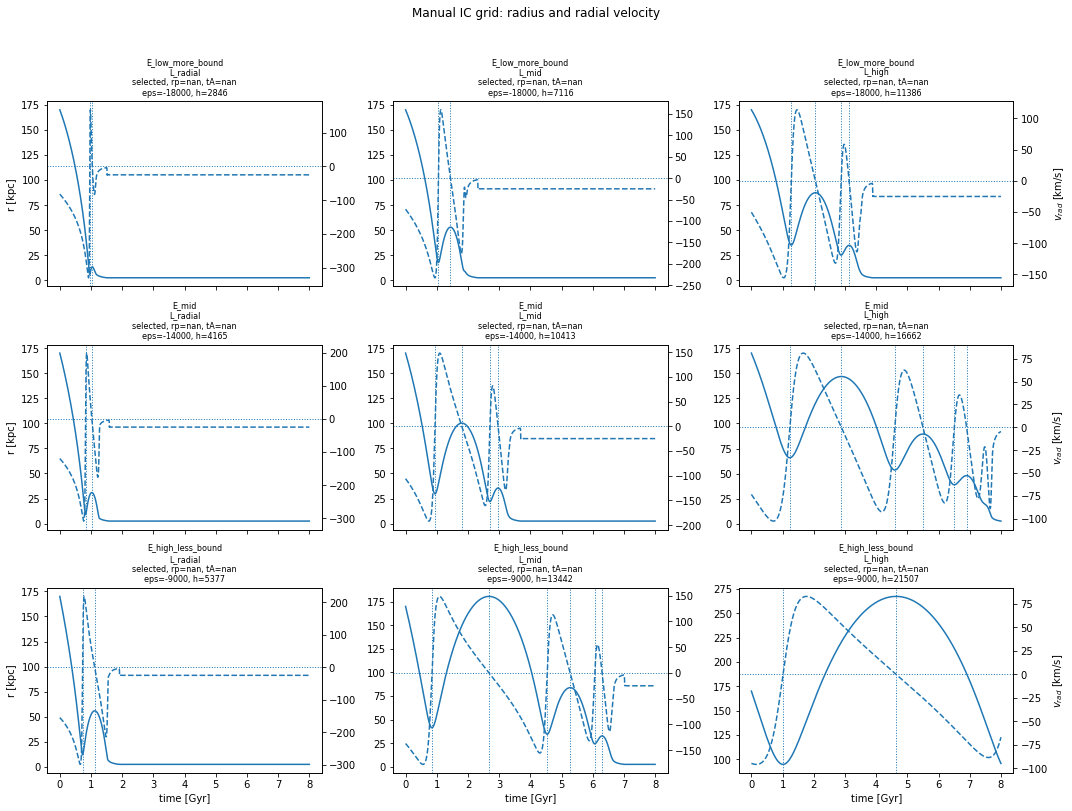

In [31]:
fig, axes = plot_manual_ic_3x3_radius_vrad_grid(
    df_fixed,
    cfg,
    mass_label="massive",
    row_labels=["E_low_more_bound", "E_mid", "E_high_less_bound"],
    col_labels=["L_radial", "L_mid", "L_high"],
    radius_log=False,
    title="Manual IC grid: radius and radial velocity",
)

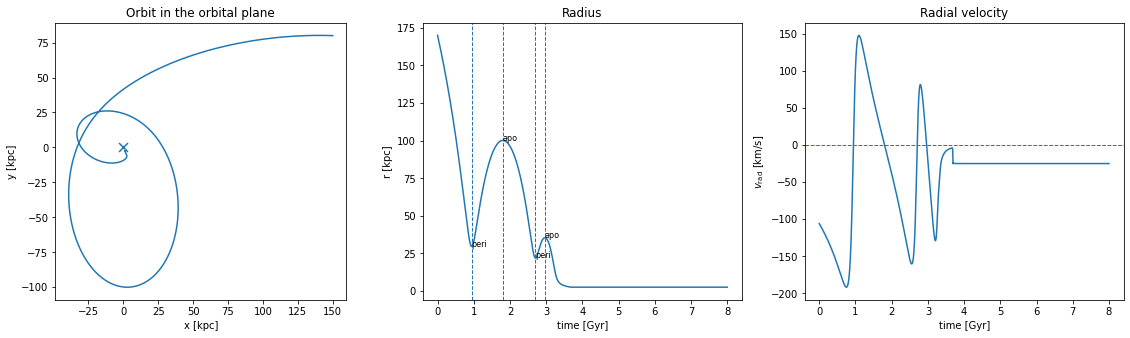

In [25]:
# Exemplo: primeira IC aceita
row = selected_orbits(df_fixed, status="selected").iloc[4]

fig, axes, res = plot_orbit(row, cfg)
plt.show()